# Ollama Python Library - Introduction
by Mjrovai @ Feb26

## Exploring Models 

In [1]:
import ollama

In [2]:
models = ollama.list()
for model in models['models']:
    print(model['model'])

smollm2:135m
smollm2:360m
hf.co/QuantFactory/SmolLM2-135M-GGUF:Q4_K_M
moondream:latest
ministral-3:3b
qwen3-vl:2b
llama3.2:3b


In [45]:
#ollama.show('llama3.2:3b')

In [11]:
info = ollama.show('llama3.2:3b')

print("Model/Format               :", getattr(info, 'model', None))
print("Parameter Size             :", getattr(info.details, 'parameter_size', None))
print("Quantization Level         :", getattr(info.details, 'quantization_level', None))
print("Family                     :", getattr(info.details, 'family', None))
print("Supported Capabilities      :", getattr(info, 'capabilities', None))
print("Date Modified (Local)      :", getattr(info, 'modified_at', None))
print("License Short              :", (str(getattr(info, 'license', None)).split('\n')[0]))
print("Key Architecture Details   :")

for key in [
    'general.architecture', 'general.finetune',
    'llama.context_length', 'llama.embedding_length', 'llama.block_count'
]:
    print(f" - {key}: {info.modelinfo.get(key)}")

Model/Format               : None
Parameter Size             : 3.2B
Quantization Level         : Q4_K_M
Family                     : llama
Supported Capabilities      : ['completion', 'tools']
Date Modified (Local)      : 2026-02-09 14:45:41.865572-03:00
License Short              : LLAMA 3.2 COMMUNITY LICENSE AGREEMENT
Key Architecture Details   :
 - general.architecture: llama
 - general.finetune: Instruct
 - llama.context_length: 131072
 - llama.embedding_length: 3072
 - llama.block_count: 28


### Llama3.2:3B Walk Through

We’re looking at a 3.2B‑parameter Llama‑family instruction model, quantized for efficient local use. Let's walk through each field and what it implies in practice.

#### High‑level identity

- **Family: `llama`**  
  This is an LLaMA‑style transformer (same general architecture as Meta’s Llama 3.x family): decoder‑only transformer, causal (left‑to‑right) language model, multi‑head attention, MLP blocks, rotary position embeddings, etc.  
- **Parameter Size: `3.2B`**  
  The base model has about **3.2 billion trainable parameters**. This puts it in the “small to mid‑size” range: much larger than tiny 1B models, but far below 7B/8B/70B. On a modern CPU/GPU it’s suitable for real‑time-ish local inference, especially after quantization.

#### Instruction tuning and capabilities

- **`general.finetune: Instruct`**  
  The base Llama model has been fine‑tuned on instruction‑following data (Q&A, chat, tool‑using examples). This means:
  - It expects prompts that look like “user asks → model answers”.
  - It tends to produce helpful, direct responses instead of random continuation.
  - It may follow some chat‑style formatting conventions (system/user/assistant turns) depending on the template used in our runtime.
- **Supported Capabilities: `['completion', 'tools']`**  
  - `completion`: classic text generation—answering questions, writing code, explanations, etc.  
  - `tools`: the model has been trained/fine‑tuned to **call tools/functions** (e.g., JSON function calls) when the host runtime exposes them, so it can decide “I should call a function to get data” vs just answering from its own weights.  
>This doesn’t mean the tools are built into the model; it means it knows how to format tool calls when the surrounding system supports them.

#### Quantization: `Q4_K_M`

- **Quantization Level: `Q4_K_M`**  
  This is a **4‑bit K‑quantization variant**, typically from GGUF/GGML families:
  - Weights are stored at about 4 bits per parameter instead of 16/32, drastically reducing RAM and disk size.
  - `K_M` is a specific quantization scheme/variant that balances compression with accuracy; it’s usually better than older naive 4‑bit schemes (higher effective precision per parameter block).
- **Practical impact**:
  - Much **smaller VRAM/RAM requirement**, so a 3.2B model can run comfortably on a Pi 5 + NPU/GPU or a modest desktop GPU.
  - Slight drop in raw quality vs the original FP16/FP32 model, but for many tasks (chat, simple coding, small reasoning tasks) it’s still very usable.
  - Ideal for **edge** or low‑power devices.

#### Context and embedding sizes

- **`llama.context_length: 131072`**  
  Context length is **131,072 tokens (~131k)**:
  - This is a very large context window (comparable to “128k context” models).
  - It can ingest long documents, multiple files, or extended conversations without immediately forgetting earlier content.
  - Under the hood, this usually implies some form of advanced attention scaling (e.g., RoPE scaling, attention optimizations, maybe sparse/flash attention), but the key user effect is: we can feed a lot of text at once.
- **`llama.embedding_length: 3072`**  
  The hidden/embedding dimension is **3072**:
  - Each token is represented as a 3072‑dimensional vector internally.
  - This roughly sets the “width” of the model: **wider models can represent richer patterns but cost more per token**.
  - Often, this is also the size of embeddings we’d extract if using the model as an encoder (assuming our runtime supports that mode).

#### Depth / layers

- **`llama.block_count: 28`**  
  The transformer has **28 decoder blocks (layers)**:
  - More layers typically improve the model’s ability to perform multi‑step reasoning and to build hierarchical representations.
  - For 3.2B parameters, 28 layers with width 3072 is a sensible trade‑off (moderately deep, not extremely wide).
  - Compared with a 7B model (~32–40 layers, 4k+ width), this will be less capable on very complex reasoning or coding, but noticeably more capable than 1B‑class models.

#### License and usage

- **License Short: `LLAMA 3.2 COMMUNITY LICENSE AGREEMENT`**  
  - It’s under a **Llama community license**, not pure open source.
  - Typically allows broad **research and many commercial uses**, but with conditions (e.g., restrictions around competition, misuse, or deployment size).  
  - We should read the exact license text bundled with the model before using it in commercial products, especially at scale.

#### “Model/Format: None”

- **Model/Format: `None`**  
  This usually means the *frontend* (e.g., your UI or manager) didn’t detect a specific “format template” (like “chat”, “instruct”, “plain”) beyond knowing it’s Llama:
  - The underlying file is probably something like a **GGUF** or similar binary weight file.
  - Prompt formatting will depend on our runtime’s default “llama‑instruct” template; if nothing is configured, we may need to wrap instructions manually (system/user style or clear “You are an assistant…” preamble).

#### What this model is good for

Given all this, this particular 3.2B Llama‑instruct, Q4_K_M:

- Runs well on **CPUs and small GPUs** and is feasible on **Raspberry Pi 5** if we’re careful.  
- Handles **long contexts** (docs, codebases, multi‑file RAG) thanks to the 131k context window.  
- Suitable for:
  - General Q&A / explanation.
  - Light coding assistance and script generation.
  - Tool‑calling workflows (e.g., local agents that call shell/HTTP tools).
- Less suitable than a larger 7B/8B model for:
  - Very complex multi‑step reasoning.
  - Large‑codebase refactoring or advanced programming tasks.
  - High‑quality, nuanced long‑form writing.

## Ollama Generate

In [12]:
response = ollama.generate(
    model="llama3.2:3b",
    prompt="What is the capital of Brazil"
)
print(response['response'])

The capital of Brazil is Brasília.


In [13]:
MODEL="llama3.2:3b"

In [14]:
def simple_query(prompt, model=MODEL):
    response = ollama.generate(
    model=MODEL,
    prompt=prompt
    )
    return response

In [15]:
response = simple_query ("What is the capital of Peru?")
response

GenerateResponse(model='llama3.2:3b', created_at='2026-02-26T18:58:30.730414614Z', done=True, done_reason='stop', total_duration=2307368739, load_duration=343767495, prompt_eval_count=32, prompt_eval_duration=722764406, eval_count=8, eval_duration=1229567370, response='The capital of Peru is Lima.', thinking=None, context=[128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 271, 128009, 128006, 882, 128007, 271, 3923, 374, 279, 6864, 315, 48847, 30, 128009, 128006, 78191, 128007, 271, 791, 6864, 315, 48847, 374, 63053, 13], logprobs=None)

In [17]:
import json
print(json.dumps(response.__dict__, indent=2))

{
  "model": "llama3.2:3b",
  "created_at": "2026-02-26T18:58:30.730414614Z",
  "done": true,
  "done_reason": "stop",
  "total_duration": 2307368739,
  "load_duration": 343767495,
  "prompt_eval_count": 32,
  "prompt_eval_duration": 722764406,
  "eval_count": 8,
  "eval_duration": 1229567370,
  "response": "The capital of Peru is Lima.",
  "thinking": null,
  "context": [
    128006,
    9125,
    128007,
    271,
    38766,
    1303,
    33025,
    2696,
    25,
    6790,
    220,
    2366,
    18,
    271,
    128009,
    128006,
    882,
    128007,
    271,
    3923,
    374,
    279,
    6864,
    315,
    48847,
    30,
    128009,
    128006,
    78191,
    128007,
    271,
    791,
    6864,
    315,
    48847,
    374,
    63053,
    13
  ],
  "logprobs": null
}


In [18]:
print(f"{response['response']}")

The capital of Peru is Lima.


In [19]:
# The time taken for the model to generate the response is in nanoseconds
print(f"Total Duration: {(response['total_duration']/1e9):.2f} seconds")

Total Duration: 2.31 seconds


In [20]:
print(f"eval_count: {response['eval_count']}")
print(f"eval_duration: {(response['eval_duration']/1e9):.2f} s")
print(f"eval_rate: {response['eval_count']/(response['eval_duration']/1e9):.2f} tokens/s")

eval_count: 8
eval_duration: 1.23 s
eval_rate: 6.51 tokens/s


### Streaming with ollama.generate()

To stream output from `ollama.generate()` in Python, we should set `stream=True` and iterate through the returned generator to print each chunk as it's produced. This enables real-time response streaming, similar to chat models

In [21]:
stream = ollama.generate(
    model='llama3.2:3b',
    prompt='Tell me an interesting fact about Brazil',
    stream=True
)

for chunk in stream:
    print(chunk['response'], end='', flush=True)

Here's an interesting fact about Brazil:

Brazil has over 2,000 indigenous languages spoken across its vast territory. This is more than any other country in the world, and it's a testament to the rich cultural diversity of the Brazilian people. In fact, Brazil has so many different languages that it's estimated that nearly one-third of all languages spoken globally are native to Brazil.

- Each `chunk['response']` is a part of the generated text, streamed as it's created
- This allows responsive, real-time interaction in the terminal or UI.

This approach is ideal for long or complex generations, making the user experience feel faster and more interactive

## Ollama Chat

In [22]:
response = ollama.chat(
    model='llama3.2:3b',
    messages=[
        {'role': 'user', 'content': 'What is the capital of Malawi?'},
    ]
)
print(response['message']['content'])

The capital of Malawi is Lilongwe.


In [23]:
for chunk in ollama.chat(
    model='llama3.2:3b',
    messages=[{'role': 'user', 'content': 'Tell me a joke.'}],
    stream=True
):
    print(chunk['message']['content'], end='', flush=True)

Why don't eggs tell jokes?

Because they'd crack each other up!

## Key Advanced Features

Ollama’s Python API offers numerous advanced features beyond specifying a model, prompt (or messages), and streaming responses. These options let us customize generations, manage context, control system prompts, handle tool-calling, and more, enabling robust and intelligent LLM applications

#### System Prompt 
  Add a `system` parameter to set overall instructions or behavior for the model (useful for role assignment and tone control)

In [27]:
response = ollama.generate(model='llama3.2:3b', 
                prompt='Tell about the industry in 100 words. Use plain text.', 
                system='You are an expert on Brazil.', 
                stream=False)
print(response['response'])

Brazil's economy is a mixed bag, with both strengths and weaknesses. The country has a large and diverse agricultural sector, producing crops such as soybeans, coffee, and sugarcane. The mining industry is also significant, with iron ore being the largest export commodity. Additionally, Brazil has a growing manufacturing sector, particularly in the automotive and electronics industries. However, the country's economy is heavily reliant on external factors, such as global demand for its exports, and is vulnerable to fluctuations in commodity prices. Overall, diversification efforts are underway to reduce dependence on a few key sectors and boost growth.


#### Temperature and Sampling 

Control creativity/randomness via `temperature`, and customize output style with extra settings like `top_p` and `num_ctx` (context window size)

In [28]:
response = ollama.generate(
    model='llama3.2:3b', 
    prompt='Whay the sky is blue? Answer it in 100 words', 
    options={'temperature':0.1}, 
    stream=True)
for chunk in response:
    print(chunk['response'], end='', flush=True)

The sky appears blue due to a phenomenon called Rayleigh scattering, named after British physicist Lord Rayleigh. When sunlight enters Earth's atmosphere, it encounters tiny molecules of gases such as nitrogen and oxygen. These molecules scatter the shorter (blue) wavelengths of light more than the longer (red) wavelengths, resulting in the blue color we see. This effect is more pronounced during the daytime when the sun is overhead, causing the sky to appear blue. The scattering effect also explains why the sky can take on hues of red and orange during sunrise and sunset.

In [32]:
response = ollama.generate(
    model='llama3.2:3b', 
    prompt='Whay the sky is blue? Answer it in 100 words', 
    options={'temperature':1.0}, 
    stream=True)
for chunk in response:
    print(chunk['response'], end='', flush=True)

The sky appears blue because of a phenomenon called scattering. When sunlight enters Earth's atmosphere, it encounters tiny molecules of gases such as nitrogen and oxygen. These molecules scatter the shorter, blue wavelengths of light more than the longer, red wavelengths. As a result, the blue light is dispersed in all directions and reaches our eyes from every part of the sky, giving it its characteristic blue color. This effect is more pronounced during the day when the sun is overhead and the atmosphere is clearer, resulting in a bright blue sky.

In [29]:
response = ollama.chat(
    messages=[
        {"role": "user", "content": "Poetically describe Paris in one short sentence"},
    ],
    model='llama3.2:3b',
    options={"temperature": 1.0}  # Setting temperature to 1.0 for more creativity
)
print(response['message']['content'])

Paris whispers secrets of timeless romance, beauty, and artistry on the soft petals of morning mist.


In [30]:
response = ollama.chat(
    messages=[
        {"role": "user", "content": "Poetically describe Paris in one short sentence"},
    ],
    model='llama3.2:3b',
    options={"temperature": 0.1}  # Setting temperature to 0.1 for less creativity
)
print(response['message']['content'])

Softly glowing City of Light, where moonlit Seine whispers secrets to the Eiffel's iron lace.


#### More Options

Besides `temperature`, we can control a lot via `options={...}` in `ollama.generate`. Key ones:

**Sampling/style**

- `top_k`: limit candidates to top K tokens each step, e.g., `top_k=40`
- `top_p`: nucleus sampling cutoff, e.g., `top_p=0.9`
- `repeat_penalty`: discourage repetition, e.g., `repeat_penalty=1.1`
- `seed`: fixed seed for reproducible outputs

**Length/context**

- `num_predict`: max new tokens, e.g., `num_predict=256`
- `num_ctx`: context window (tokens to keep in RAM), e.g., `num_ctx=4096`

Putting it together in your code:


In [41]:
response = ollama.generate(
    model='llama3.2:3b',
    prompt='Why is the sky blue?',
    options={
        'temperature': 0.1,
        'top_p': 0.9,
        'top_k': 40,
        'repeat_penalty': 1.1,
        'num_predict': 50, # Limit the answer
        'num_ctx': 4096,
        'seed': 42,
    },
    stream=True,
)
for chunk in response:
    print(chunk['response'], end='', flush=True)


The sky appears blue because of a phenomenon called Rayleigh scattering, named after the British physicist Lord Rayleigh, who first described it in the late 19th century.

Here's what happens:

1. When sunlight enters Earth's atmosphere, it encounters

In [42]:
response = ollama.generate(
    model='llama3.2:3b',
    prompt= 'What color is the sky at different times of the day? Respond using JSON',
    options={
        'temperature': 0.1,
        'top_p': 0.9,
        'top_k': 40,
        'repeat_penalty': 1.1,
        'num_predict': 128,
        'num_ctx': 4096,
        'seed': 42,
    },
    stream=True,
)
for chunk in response:
    print(chunk['response'], end='', flush=True)


Here's a JSON representation of the typical colors of the sky at different times of the day:

```
{
  "daytime": {
    "morning": "light blue",
    "afternoon": "bright blue",
    "evening": "pale orange"
  },
  "sunset": {
    "early": "soft pink",
    "mid": "warm orange",
    "late": "deep crimson"
  },
  "nighttime": {
    "dawn": "dark indigo",
    "twilight": "deep blue",
    "full night": "black"
  }
}
```



#### How `top_k` and `top_p` affect generation

`top_k` and `top_p` both control how *random* and *diverse* the model’s next tokens can be, but they do it in different ways.

**top_k: fixed shortlist size**

- At each step, the model ranks all possible next tokens by probability.  
- **top_k = K** means: keep only the **K most likely tokens**, set all others to probability 0, then sample from those K.  
- Effects:
  - **Small k (1–20)** → very focused, deterministic, “on‑rails”; less creative, fewer weird tokens.
  - **Large k (50–200+)** → more variety and creativity; higher chance of unusual or off‑topic words.
- Extreme:
  - `top_k = 1` → greedy decoding: always pick the single most likely token, almost no randomness.

**top_p: dynamic shortlist by probability mass**

- Tokens are sorted by probability.  
- Starting from the top, you add tokens until their **cumulative probability ≥ p**. Then you sample only from that set.  
- **top_p = 0.9** means: “consider just enough top tokens to cover 90% of the probability mass”.
- Effects:
  - In **confident** situations (one token is clearly best), the shortlist may be very small → behavior similar to low k.
  - In **uncertain** situations (probabilities spread out), more tokens enter the shortlist → more exploration.
- Typical:
  - `top_p ≈ 0.9–0.95` is a common sweet spot for natural but not too wild text.

How they feel in practice

- Lower **top_k / top_p** → safer, more repetitive, less surprising.  
- Higher **top_k / top_p** → more diverse, more creative, but also more risk of nonsense.

We can use them together—for example, `top_k=40, top_p=0.9`—where `top_k` gives a hard cap and `top_p` then trims that set by probability mass.


> Some models have `temperature`, `top_p`, and `top_q` defined in the Modelfile. The ones that do not have (as in Llama 3.2:3B) use Ollama’s defaults for this model at runtime. `temperature 0.3`, `top_p 0.9`and `top_k 40`

## Memory

In [47]:
MODEL="llama3.2:3b"
response = simple_query ("What is the capital of Brazil?")
print(f"{response['response']}")

The capital of Brazil is Brasília.


In [48]:
response = simple_query ("And Peru?")
print(f"{response['response']}")

Peru is a country located in western South America, bordered by Ecuador to the north, Colombia to the northeast, Brazil to the east, Bolivia to the southeast, and Chile to the south. Here are some key facts about Peru:

 Geography:
 Perú has a diverse geography that includes the Andes Mountains, the Amazon rainforest, and the coastal desert.

 Culture:
Peruvian culture is rich and diverse, with influences from indigenous, Spanish, African, and Asian traditions. The country is known for its vibrant textiles, music, and dance.

 History:
Peru has a long and complex history, with evidence of human habitation dating back to 10,000 BCE. The Inca Empire was one of the most powerful empires in pre-Columbian America, and the country remains home to many Inca ruins and artifacts.

 Economy:
Peru is one of the fastest-growing economies in South America, driven by its rich natural resources, including copper, gold, and oil.

 Tourism:
Peru is a popular tourist destination, with attractions like M

### Including "Memory"

#### using ollama.chat()

In [49]:
# Initialize conversation history
conversation = []

# Function to chat with memory
def chat_with_memory(prompt, model=MODEL):
    global conversation
    
    # Add user message to conversation
    conversation.append({"role": "user", "content": prompt})
    
    # Generate response with conversation history
    response = ollama.chat(
        model=MODEL,
        messages=conversation
    )
    
    # Add assistant's response to conversation history
    conversation.append(response["message"])
    
    # Return just the response text
    return response["message"]["content"]

In [50]:
# Question
prompt = "What is the capital of Brazil"
print(chat_with_memory(prompt))

# Ask a follow-up question that relies on memory
follow_up = "And Peru?"
print(chat_with_memory(follow_up))

The capital of Brazil is Brasília.
The capital of Peru is Lima.


## Image Description

In [51]:
import time
import numpy as np
import matplotlib.pyplot as plt
from picamera2 import Picamera2
from PIL import Image

In [52]:
def capture_image(image_path):
    # Initialize camera
    picam2 = Picamera2() # default is index 0
    
    # Configure the camera
    config = picam2.create_still_configuration(main={"size": (520, 520)})
    picam2.configure(config)
    picam2.start()
    
    # Wait for the camera to warm up
    time.sleep(2)
    
    # Capture image
    picam2.capture_file(image_path)
    print("Image captured: "+image_path)
    
    # Stop camera
    picam2.stop()
    picam2.close()

In [53]:
IMG_PATH = "/home/mjrovai/Documents/OLLAMA/capt_image.jpg"
capture_image(IMG_PATH)

[48:54:05.014928056] [220113]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[48:54:05.027593459] [284772]  INFO RPI pisp.cpp:720 libpisp version 1.3.0
[48:54:05.047240202] [284772]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[48:54:05.057805100] [284772]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36' for pipeline handler rpi/pisp
[48:54:05.057829082] [284772]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 to CFE device /dev/media0 and ISP device /dev/media2 using PiSP variant BCM2712_C0
[48:54:05.063532573] [220113]  INFO Camera camera.cpp:1215 configuring streams: (0) 520x520-BGR888/sRGB (1) 640x480-GBRG_PISP_COMP1/RAW
[48:54:05.063663186] [284772]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10/RAW - Selected CFE format: 640x480-PC1g/R

Image captured: /home/mjrovai/Documents/OLLAMA/capt_image.jpg


In [54]:
def show_image(image_path):
    img = Image.open(image_path)
    
    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Captured Image")
    plt.show()

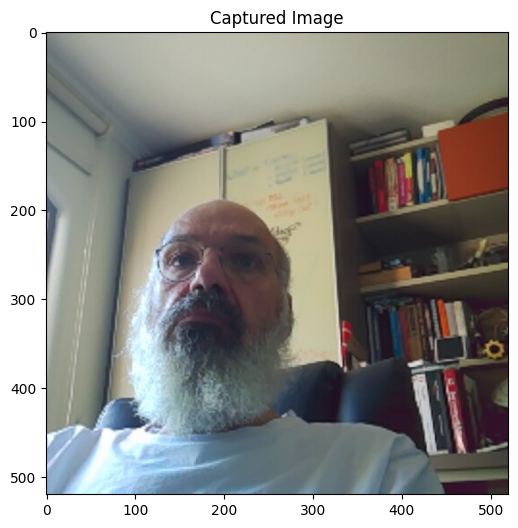

In [55]:
show_image(IMG_PATH)

In [56]:
def image_description(img_path, model):
    with open(img_path, 'rb') as file:
        response = ollama.chat(
            model=model,
            messages=[
              {
                'role': 'user',
                'content': '''return the description of the image''',
                'images': [file.read()],
              },
            ],
            options = {
              'temperature': 0,
              }
      )
    return response

In [57]:
MODEL = "moondream:latest"

In [58]:
IMG_PATH

'/home/mjrovai/Documents/OLLAMA/capt_image.jpg'

In [59]:
response = image_description(IMG_PATH, MODEL)
caption = response['message']['content']
print ("\n==> AI Response:", caption)


==> AI Response: 
The image features a bearded man wearing glasses sitting in an office chair. He is looking directly at the camera, giving off a serious expression. The room has several bookshelves filled with various books and objects on them, indicating that it could be a workspace or study area. A window can also be seen in the background, suggesting natural light entering the space.


In [60]:
print(f"\n[INFO] ==> Total Duration: {(response['total_duration']/1e9):.2f} seconds")


[INFO] ==> Total Duration: 75.69 seconds


## Putting all together

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt
from picamera2 import Picamera2
from PIL import Image

In [16]:
IMG_PATH = "/home/mjrovai/Documents/OLLAMA/SST/capt_image.jpg"
MODEL = "moondream:latest"

[4:21:07.579909448] [29797]  INFO Camera camera_manager.cpp:330 libcamera v0.5.2+99-bfd68f78
[4:21:07.590613203] [30874]  INFO RPI pisp.cpp:720 libpisp version v1.2.1 981977ff21f3 29-04-2025 (14:13:50)
[4:21:07.594080404] [30874]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[4:21:07.604675251] [30874]  INFO Camera camera_manager.cpp:220 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36' for pipeline handler rpi/pisp
[4:21:07.604694214] [30874]  INFO RPI pisp.cpp:1179 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 to CFE device /dev/media0 and ISP device /dev/media2 using PiSP variant BCM2712_C0
[4:21:07.608893589] [29797]  INFO Camera camera.cpp:1215 configuring streams: (0) 520x520-BGR888/sRGB (1) 640x480-GBRG_PISP_COMP1/RAW
[4:21:07.609014701] [30874]  INFO RPI pisp.cpp:1483 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10/RAW - Selected CFE 

Image captured: /home/mjrovai/Documents/OLLAMA/SST/capt_image.jpg


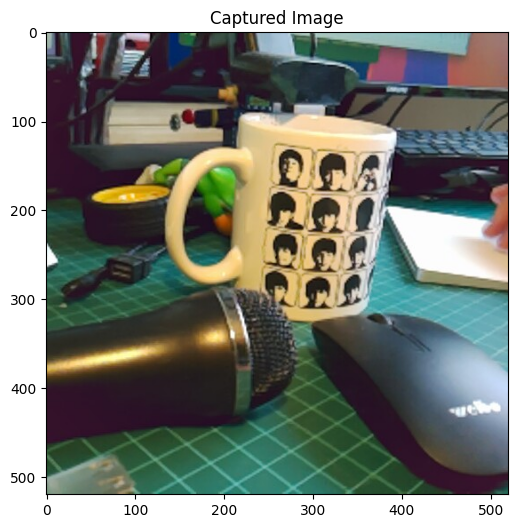


==> AI Response: 
The image features a green table with various items on it. A white mug adorned with black faces is prominently displayed, and there are several other mugs scattered around the table as well. In addition to the mugs, there's also a microphone placed near them, suggesting that this might be an office or workspace setting where someone could enjoy their coffee while recording podcasts or audio content.

A computer keyboard can be seen in the background, indicating that it is likely connected to a computer for work purposes. A mouse and a cell phone are also present on the table, further emphasizing the technology-oriented nature of this scene.

[INFO] ==> Total Duration: 62.06 seconds


In [17]:
capture_image(IMG_PATH)
show_image(IMG_PATH)
response = image_description(IMG_PATH, MODEL)
caption = response['message']['content']
print ("\n==> AI Response:", caption)
print(f"\n[INFO] ==> Total Duration: {(response['total_duration']/1e9):.2f} seconds")